# Tech Challenge - Fase 2
## Otimização de modelos de diagnóstico com Algoritmos Genéticos e LLM

Este notebook apresenta a evolução do projeto desenvolvido na **Fase 1**. O
objetivo é otimizar os hiperparâmetros dos modelos de diagnóstico, comparar os
resultados de forma reproduzível e transformar a saída numérica em uma
explicação clara usando uma LLM.

> **Aviso:** projeto exclusivamente educacional. Nenhuma saída substitui
> diagnóstico, laudo ou avaliação de profissional de saúde.

### O que será apresentado

1. preparação e auditoria dos dados;
2. análise exploratória com visualizações;
3. reprodução dos modelos baseline;
4. funcionamento e configuração do algoritmo genético;
5. resultados dos três experimentos obrigatórios;
6. comparação baseline versus otimizado;
7. interpretabilidade e explicação em linguagem natural;
8. limitações, arquitetura e conclusão.

In [1]:
from pathlib import Path
import importlib.util
import os
import sys

cwd = Path.cwd().resolve()
candidates = [cwd, cwd / 'desafio-tecnico-fase2', *cwd.parents]
project_root = next(
    (path for path in candidates if (path / 'src' / 'tech_challenge_fase2').is_dir()),
    None,
)
if project_root is None:
    raise RuntimeError('Não foi possível localizar a raiz de desafio-tecnico-fase2.')

src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

required = ('pandas', 'sklearn', 'pydantic', 'matplotlib', 'seaborn')
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    expected = project_root / '.venv' / 'Scripts' / 'python.exe'
    raise RuntimeError(
        f'Kernel incorreto. Dependências ausentes: {missing}.\n'
        f'Kernel atual: {sys.executable}\n'
        f'Selecione: Python (Tech Challenge Fase 2) ou {expected}'
    )

mpl_cache = project_root / 'tmp' / 'matplotlib'
mpl_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(mpl_cache))

print(f'Projeto: {project_root}')
print(f'Kernel:  {sys.executable}')

Projeto: C:\Users\User\Desktop\Tech Challenge\desafio-tecnico-fase2
Kernel:  C:\Users\User\Desktop\Tech Challenge\desafio-tecnico-fase2\.venv\Scripts\python.exe


In [2]:
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc
from sklearn.preprocessing import StandardScaler

from tech_challenge_fase2.data import load_diagnostic_dataset, split_dataset
from tech_challenge_fase2.explainability import prediction_context
from tech_challenge_fase2.llm import (
    DeterministicExplanationProvider,
    provider_from_environment,
)
from tech_challenge_fase2.models import build_model, classification_metrics

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
COLORS = {
    'Benigno': '#2A9D8F',
    'Maligno': '#E76F51',
    'Baseline': '#457B9D',
    'Otimizado (GA)': '#F4A261',
    'Destaque': '#6C5CE7',
}
plt.rcParams.update({
    'figure.figsize': (10, 5.5),
    'figure.dpi': 110,
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
})
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

---
# 1. Dados da Fase 1

O projeto procura primeiro o arquivo `desafio-tecnico-fase1/data.csv`. Caso ele
não esteja disponível, usa o dataset equivalente do scikit-learn. A variável
alvo é codificada como **1 = maligno** e **0 = benigno**.

In [ ]:
dataset = load_diagnostic_dataset()
X = dataset.features.copy()
y = dataset.target.copy()
labels = y.map({0: 'Benigno', 1: 'Maligno'}).rename('diagnóstico')

overview = pd.DataFrame({
    'Indicador': ['Observações', 'Variáveis', 'Casos benignos', 'Casos malignos', 'Valores ausentes'],
    'Valor': [len(X), X.shape[1], int((y == 0).sum()), int((y == 1).sum()), int(X.isna().sum().sum())],
})

display(Markdown(
    f'''
<div style="display:flex; gap:14px; flex-wrap:wrap; margin:12px 0 20px 0; color: #333;">
  <div style="padding:16px 20px; background:#E8F5F2; border-left:5px solid #2A9D8F; border-radius:8px;"><b>569</b><br>observações</div>
  <div style="padding:16px 20px; background:#EEF3F8; border-left:5px solid #457B9D; border-radius:8px;"><b>30</b><br>variáveis</div>
  <div style="padding:16px 20px; background:#FFF0EB; border-left:5px solid #E76F51; border-radius:8px;"><b>{int((y == 1).sum())}</b><br>casos malignos</div>
  <div style="padding:16px 20px; background:#F3F0FF; border-left:5px solid #6C5CE7; border-radius:8px;"><b>{int(X.isna().sum().sum())}</b><br>valores ausentes</div>
</div>
'''
))
display(overview.style.hide(axis='index').set_properties(**{'text-align': 'left'}))
print(f'Fonte utilizada: {dataset.source}')


<div style="display:flex; gap:14px; flex-wrap:wrap; margin:12px 0 20px 0;">
  <div style="padding:16px 20px; background:#E8F5F2; border-left:5px solid #2A9D8F; border-radius:8px;"><b>569</b><br>observações</div>
  <div style="padding:16px 20px; background:#EEF3F8; border-left:5px solid #457B9D; border-radius:8px;"><b>30</b><br>variáveis</div>
  <div style="padding:16px 20px; background:#FFF0EB; border-left:5px solid #E76F51; border-radius:8px;"><b>212</b><br>casos malignos</div>
  <div style="padding:16px 20px; background:#F3F0FF; border-left:5px solid #6C5CE7; border-radius:8px;"><b>0</b><br>valores ausentes</div>
</div>


Indicador,Valor
Observações,569
Variáveis,30
Casos benignos,357
Casos malignos,212
Valores ausentes,0


Fonte utilizada: C:\Users\User\Desktop\Tech Challenge\desafio-tecnico-fase1\data.csv


In [4]:
sample = X.head().copy()
sample.insert(0, 'diagnóstico', labels.head())
display(sample.style.background_gradient(cmap='Blues', subset=sample.columns[1:7]).format(precision=3))

,diagnóstico,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,Maligno,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,Maligno,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,Maligno,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,Maligno,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,Maligno,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


## 1.1 Distribuição das classes

Há mais casos benignos do que malignos. A divisão treino/teste e a validação
cruzada serão estratificadas para preservar essa proporção.

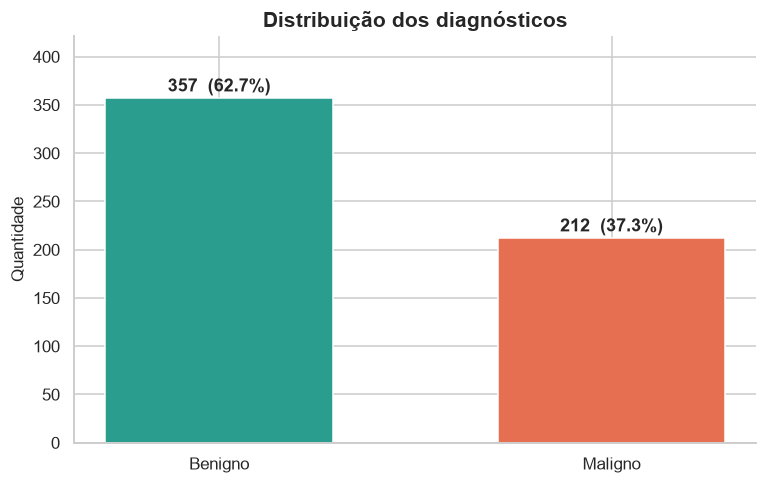

In [5]:
class_counts = labels.value_counts().reindex(['Benigno', 'Maligno'])
class_percent = class_counts / class_counts.sum()

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=[COLORS['Benigno'], COLORS['Maligno']],
    width=0.58,
)
for bar, count, percent in zip(bars, class_counts, class_percent):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 7,
        f'{count}  ({percent:.1%})',
        ha='center',
        fontweight='bold',
    )
ax.set(title='Distribuição dos diagnósticos', xlabel='', ylabel='Quantidade')
ax.set_ylim(0, class_counts.max() * 1.18)
sns.despine(ax=ax)
plt.show()

## 1.2 Distribuição das variáveis mais relevantes

As curvas abaixo permitem observar como algumas medições se comportam entre as
duas classes. Sobreposição é esperada: nenhuma variável isolada deve ser tratada
como diagnóstico.

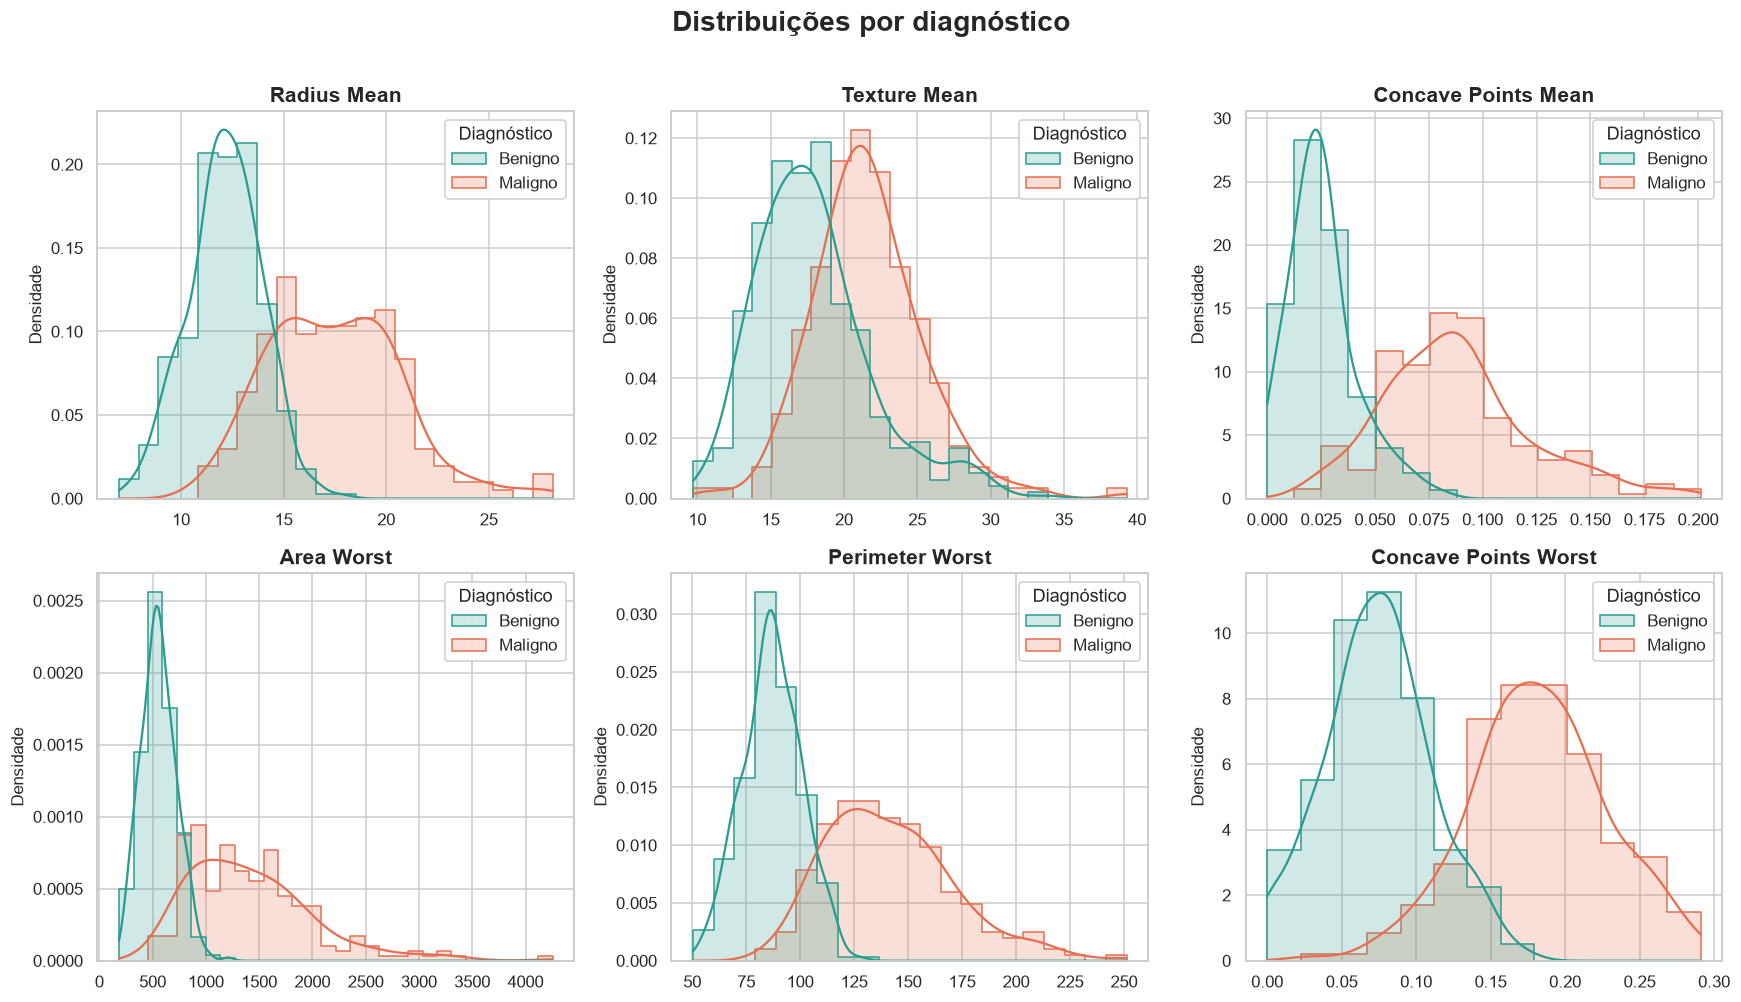

In [6]:
key_features = [
    'radius_mean', 'texture_mean', 'concave points_mean',
    'area_worst', 'perimeter_worst', 'concave points_worst',
]
available_features = [feature for feature in key_features if feature in X.columns]
eda = X.copy()
eda['Diagnóstico'] = labels

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feature in zip(axes.flat, available_features):
    sns.histplot(
        data=eda,
        x=feature,
        hue='Diagnóstico',
        hue_order=['Benigno', 'Maligno'],
        palette=[COLORS['Benigno'], COLORS['Maligno']],
        element='step',
        stat='density',
        common_norm=False,
        kde=True,
        alpha=0.22,
        ax=ax,
    )
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Densidade')
for ax in axes.flat[len(available_features):]:
    ax.set_visible(False)
fig.suptitle('Distribuições por diagnóstico', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 1.3 Correlação com o diagnóstico

A matriz mostra as variáveis com maior correlação absoluta com a classe. Ela é
útil para exploração, mas não demonstra causalidade.

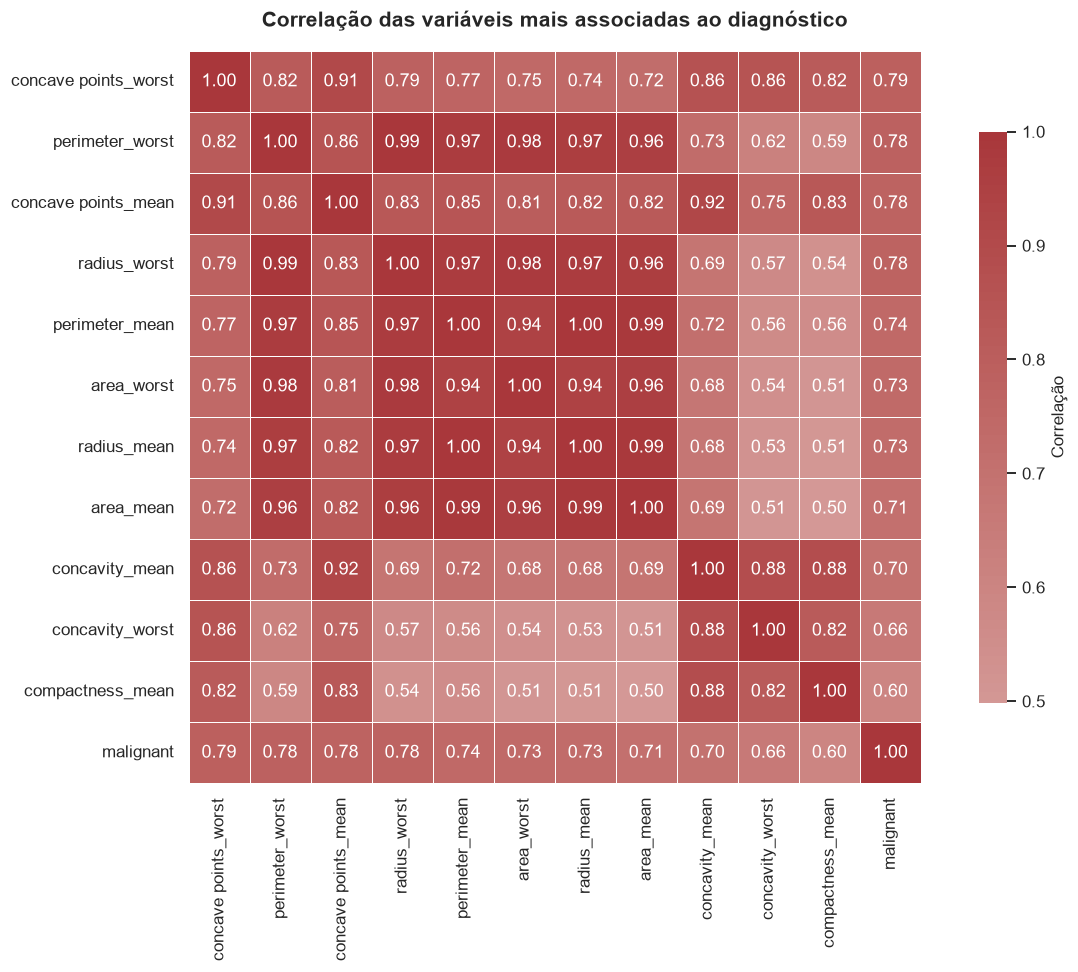

In [7]:
corr_frame = X.copy()
corr_frame['malignant'] = y
target_corr = corr_frame.corr(numeric_only=True)['malignant'].drop('malignant').abs()
top_corr_features = target_corr.nlargest(11).index.tolist()
heatmap_columns = top_corr_features + ['malignant']

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_frame[heatmap_columns].corr(),
    cmap='vlag',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.78, 'label': 'Correlação'},
    ax=ax,
)
ax.set_title('Correlação das variáveis mais associadas ao diagnóstico', pad=16)
plt.tight_layout()
plt.show()

## 1.4 Visualização em duas dimensões com PCA

O PCA reduz as 30 variáveis para dois componentes. Ele é utilizado somente para
visualização; os modelos continuam sendo treinados com todas as variáveis.

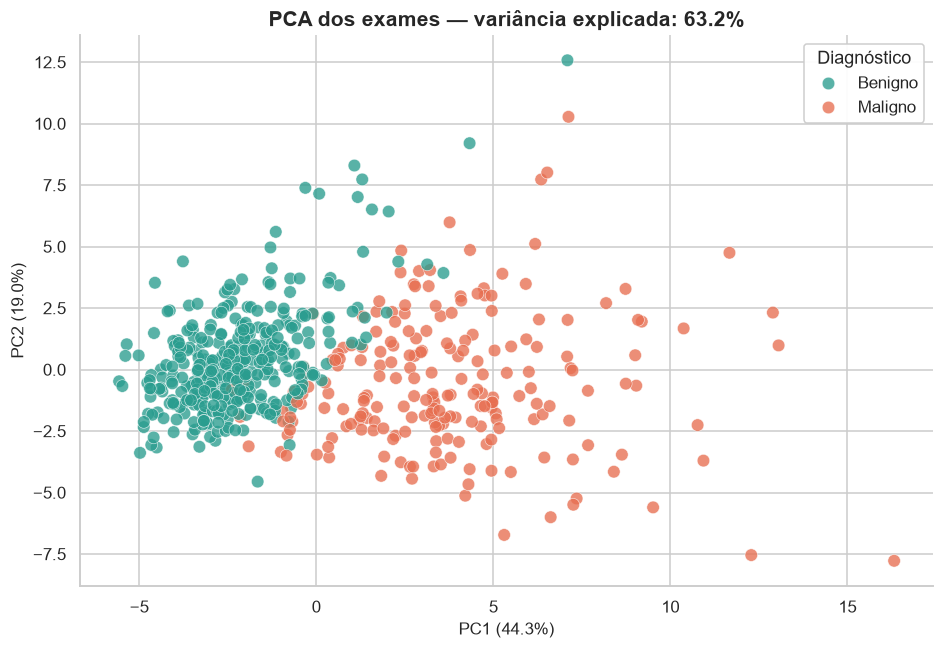

In [8]:
scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(scaled)
pca_frame = pd.DataFrame(components, columns=['PC1', 'PC2'])
pca_frame['Diagnóstico'] = labels.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6.5))
sns.scatterplot(
    data=pca_frame,
    x='PC1',
    y='PC2',
    hue='Diagnóstico',
    hue_order=['Benigno', 'Maligno'],
    palette=[COLORS['Benigno'], COLORS['Maligno']],
    s=68,
    alpha=0.78,
    edgecolor='white',
    linewidth=0.4,
    ax=ax,
)
ax.set_title(
    f'PCA dos exames — variância explicada: {pca.explained_variance_ratio_.sum():.1%}'
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
sns.despine(ax=ax)
plt.show()

---
# 2. Baselines da Fase 1

A divisão replica a Fase 1: **12% para teste**, estratificação pela classe e
`random_state=6546`. O teste fica reservado e não participa da otimização.

In [9]:
split = split_dataset(dataset)

split_summary = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste'],
    'Total': [len(split.X_train), len(split.X_test)],
    'Benignos': [(split.y_train == 0).sum(), (split.y_test == 0).sum()],
    'Malignos': [(split.y_train == 1).sum(), (split.y_test == 1).sum()],
})
display(split_summary.style.hide(axis='index').format(precision=0))

Conjunto,Total,Benignos,Malignos
Treino,500,314,186
Teste,69,43,26


In [10]:
baseline_models = {}
baseline_metrics = {}
training_times = {}

for model_name in ('logistic_regression', 'random_forest'):
    model = build_model(model_name)
    started = time.perf_counter()
    model.fit(split.X_train, split.y_train)
    training_times[model_name] = time.perf_counter() - started
    baseline_models[model_name] = model
    baseline_metrics[model_name] = classification_metrics(model, split.X_test, split.y_test)

baseline_table = pd.DataFrame(baseline_metrics).T
baseline_table['training_seconds'] = pd.Series(training_times)
baseline_table = baseline_table.drop(columns='confusion_matrix')
baseline_table.index = ['Regressão Logística', 'Random Forest']

display(
    baseline_table.style
    .format({column: '{:.2%}' for column in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']})
    .format({'training_seconds': '{:.3f} s'})
    .background_gradient(cmap='YlGn', subset=['accuracy', 'recall', 'f1', 'roc_auc'])
)

,accuracy,precision,recall,f1,roc_auc,training_seconds
Regressão Logística,0.985507,1.000000,0.961538,0.980392,0.994633,0.007 s
Random Forest,0.971014,0.961538,0.961538,0.961538,0.994633,0.107 s


## 2.1 Matrizes de confusão

Cada matriz explicita acertos e erros. Em contexto médico, o quadrante mais
sensível é o de **falsos negativos**: casos malignos classificados como benignos.

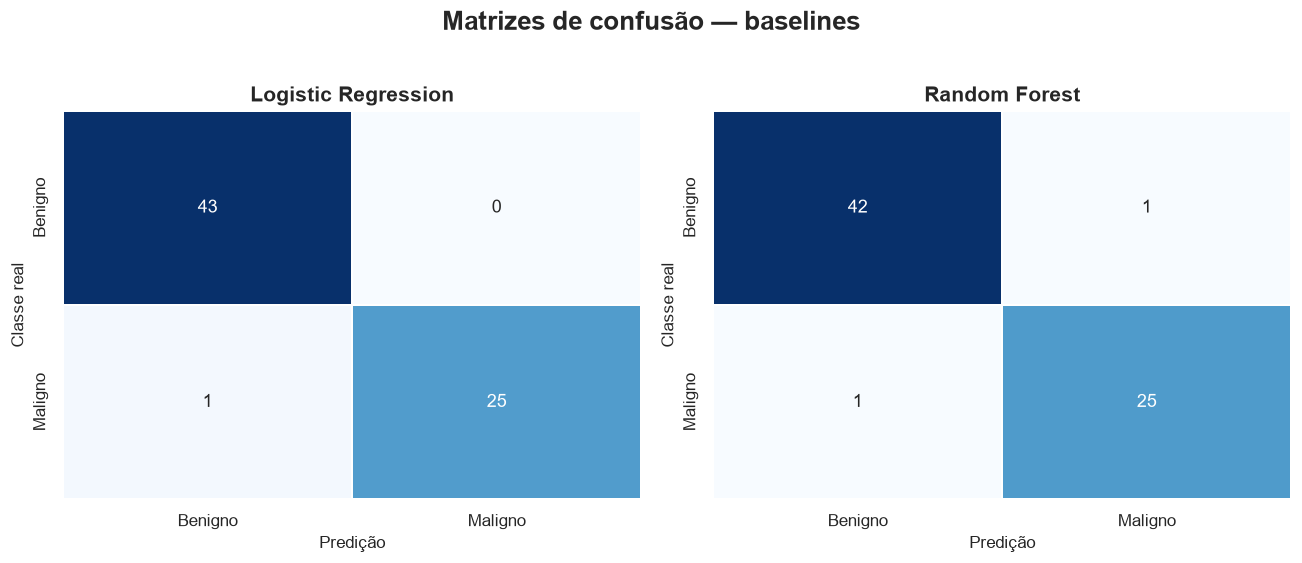

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (model_name, model) in zip(axes, baseline_models.items()):
    predictions = model.predict(split.X_test)
    matrix = pd.crosstab(
        split.y_test.map({0: 'Benigno', 1: 'Maligno'}),
        pd.Series(predictions, index=split.y_test.index).map({0: 'Benigno', 1: 'Maligno'}),
    ).reindex(index=['Benigno', 'Maligno'], columns=['Benigno', 'Maligno'], fill_value=0)
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=1, ax=ax)
    ax.set_title(model_name.replace('_', ' ').title())
    ax.set_xlabel('Predição')
    ax.set_ylabel('Classe real')
fig.suptitle('Matrizes de confusão — baselines', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2.2 Curvas ROC

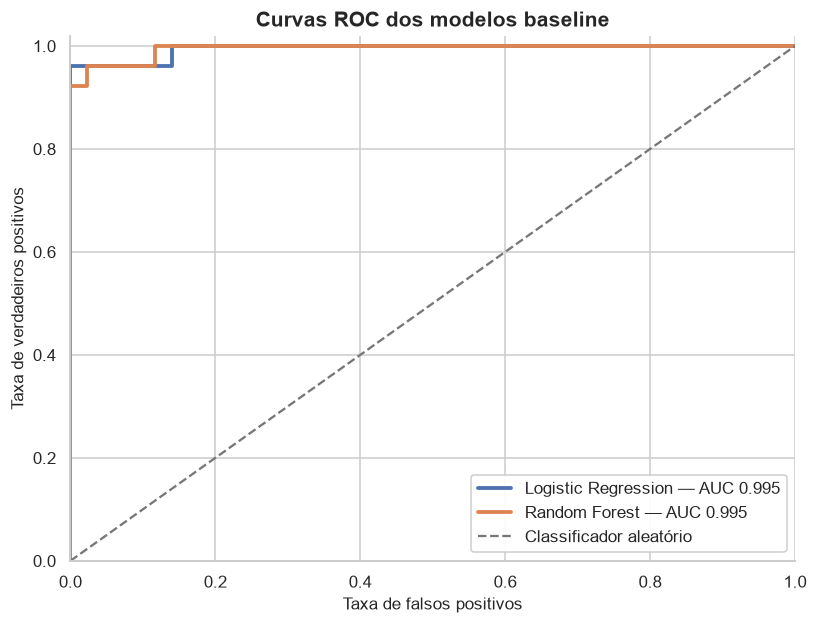

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
for model_name, model in baseline_models.items():
    probabilities = model.predict_proba(split.X_test)[:, 1]
    fpr, tpr, _ = roc_curve(split.y_test, probabilities)
    score = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2.5, label=f"{model_name.replace('_', ' ').title()} — AUC {score:.3f}")
ax.plot([0, 1], [0, 1], linestyle='--', color='#777777', label='Classificador aleatório')
ax.set(title='Curvas ROC dos modelos baseline', xlabel='Taxa de falsos positivos', ylabel='Taxa de verdadeiros positivos')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
sns.despine(ax=ax)
plt.show()

---
# 3. Otimização com Algoritmo Genético

## 3.1 Representação e operadores

Cada indivíduo representa um conjunto de hiperparâmetros.

| Modelo | Genes principais |
|---|---|
| Regressão Logística | `log10(C)`, `class_weight`, `solver` |
| Random Forest | árvores, profundidade, divisão, folha, features, balanceamento |

Operadores implementados:

- **seleção por torneio**;
- **crossover uniforme**;
- **mutação independente por gene**;
- **elitismo** dos dois melhores indivíduos;
- cache de cromossomos já avaliados.

O fitness usa validação cruzada estratificada de cinco folds:

$$fitness = 0{,}65 \times recall + 0{,}35 \times F1$$

O recall recebe maior peso para priorizar a redução de falsos negativos.

In [13]:
summary_path = project_root / 'artifacts' / 'results' / 'summary.json'
if not summary_path.is_file():
    raise RuntimeError(
        'Resultados não encontrados. Execute na raiz: python scripts/run_experiments.py'
    )

summary = json.loads(summary_path.read_text(encoding='utf-8'))
experiment_rows = []
for model_name, model_result in summary['models'].items():
    for experiment in model_result['experiments']:
        config = experiment['config']
        experiment_rows.append({
            'Modelo': model_name.replace('_', ' ').title(),
            'Configuração': config['name'].title(),
            'População': config['population_size'],
            'Gerações': config['generations'],
            'Crossover': config['crossover_rate'],
            'Mutação': config['mutation_rate'],
            'Fitness': experiment['best_fitness'],
            'Recall CV': experiment['cv_metrics']['recall'],
            'F1 CV': experiment['cv_metrics']['f1'],
            'Avaliações': experiment['evaluations'],
            'Tempo (s)': experiment['duration_seconds'],
        })

experiments_table = pd.DataFrame(experiment_rows)
display(
    experiments_table.style
    .format({'Crossover': '{:.0%}', 'Mutação': '{:.0%}', 'Fitness': '{:.4f}', 'Recall CV': '{:.2%}', 'F1 CV': '{:.2%}', 'Tempo (s)': '{:.2f}'})
    .background_gradient(cmap='Purples', subset=['Fitness'])
)

,Modelo,Configuração,População,Gerações,Crossover,Mutação,Fitness,Recall CV,F1 CV,Avaliações,Tempo (s)
0,Logistic Regression,Compacta,10,6,80%,10%,0.9712,96.76%,97.80%,21,1.30
1,Logistic Regression,Balanceada,14,8,85%,20%,0.9706,96.79%,97.56%,39,2.42
2,Logistic Regression,Exploratoria,18,10,70%,30%,0.9668,96.77%,96.51%,77,4.86
3,Random Forest,Compacta,10,6,80%,10%,0.9543,96.22%,93.97%,36,36.29
4,Random Forest,Balanceada,14,8,85%,20%,0.9561,96.23%,94.47%,90,80.21
5,Random Forest,Exploratoria,18,10,70%,30%,0.9593,96.77%,94.38%,153,165.34


## 3.2 Evolução do fitness

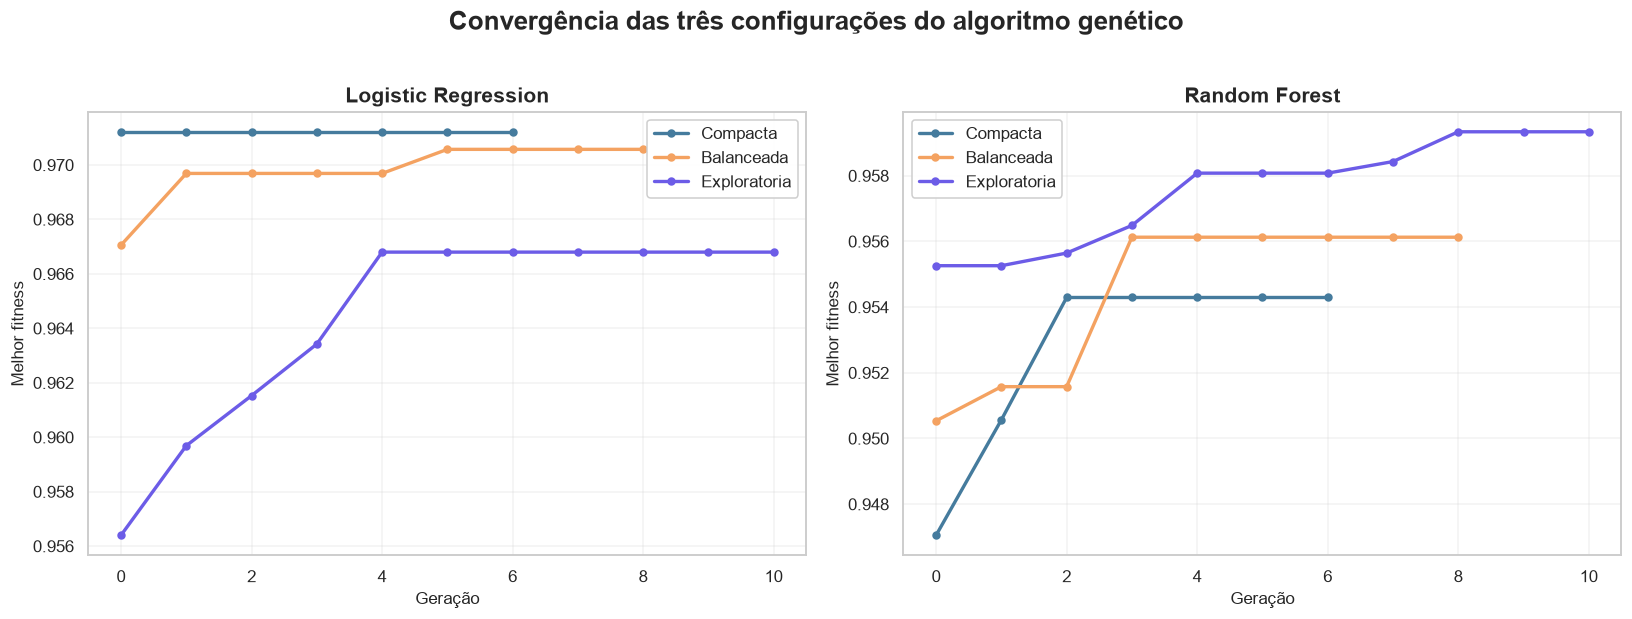

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=False)
palette = {'compacta': '#457B9D', 'balanceada': '#F4A261', 'exploratoria': '#6C5CE7'}

for ax, (model_name, model_result) in zip(axes, summary['models'].items()):
    for experiment in model_result['experiments']:
        history = pd.DataFrame(experiment['history'])
        config_name = experiment['config']['name']
        ax.plot(
            history['generation'],
            history['best'],
            marker='o',
            markersize=4.5,
            linewidth=2.2,
            color=palette[config_name],
            label=config_name.title(),
        )
    ax.set_title(model_name.replace('_', ' ').title())
    ax.set_xlabel('Geração')
    ax.set_ylabel('Melhor fitness')
    ax.legend()
    ax.grid(alpha=0.25)
fig.suptitle('Convergência das três configurações do algoritmo genético', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3.3 Melhores hiperparâmetros encontrados

In [15]:
best_parameter_rows = []
for model_name, model_result in summary['models'].items():
    best_parameter_rows.append({
        'Modelo': model_name.replace('_', ' ').title(),
        'Experimento selecionado': model_result['selected_experiment'].title(),
        'Fitness CV': model_result['best_cv_metrics']['fitness'],
        'Hiperparâmetros': json.dumps(model_result['best_parameters'], ensure_ascii=False),
    })
display(
    pd.DataFrame(best_parameter_rows).style
    .hide(axis='index')
    .format({'Fitness CV': '{:.4f}'})
    .set_properties(subset=['Hiperparâmetros'], **{'text-align': 'left'})
)

Modelo,Experimento selecionado,Fitness CV,Hiperparâmetros
Logistic Regression,Compacta,0.9712,"{""class_weight"": ""balanced"", ""solver"": ""lbfgs"", ""C"": 0.042884461196201054}"
Random Forest,Exploratoria,0.9593,"{""n_estimators"": 182, ""max_depth"": 5, ""min_samples_split"": 7, ""min_samples_leaf"": 1, ""max_features"": 0.5, ""class_weight"": ""balanced""}"


---
# 4. Comparação: baseline versus otimizado

Os hiperparâmetros são escolhidos pela validação cruzada no treino. Somente
depois da seleção o melhor indivíduo é avaliado no teste reservado.

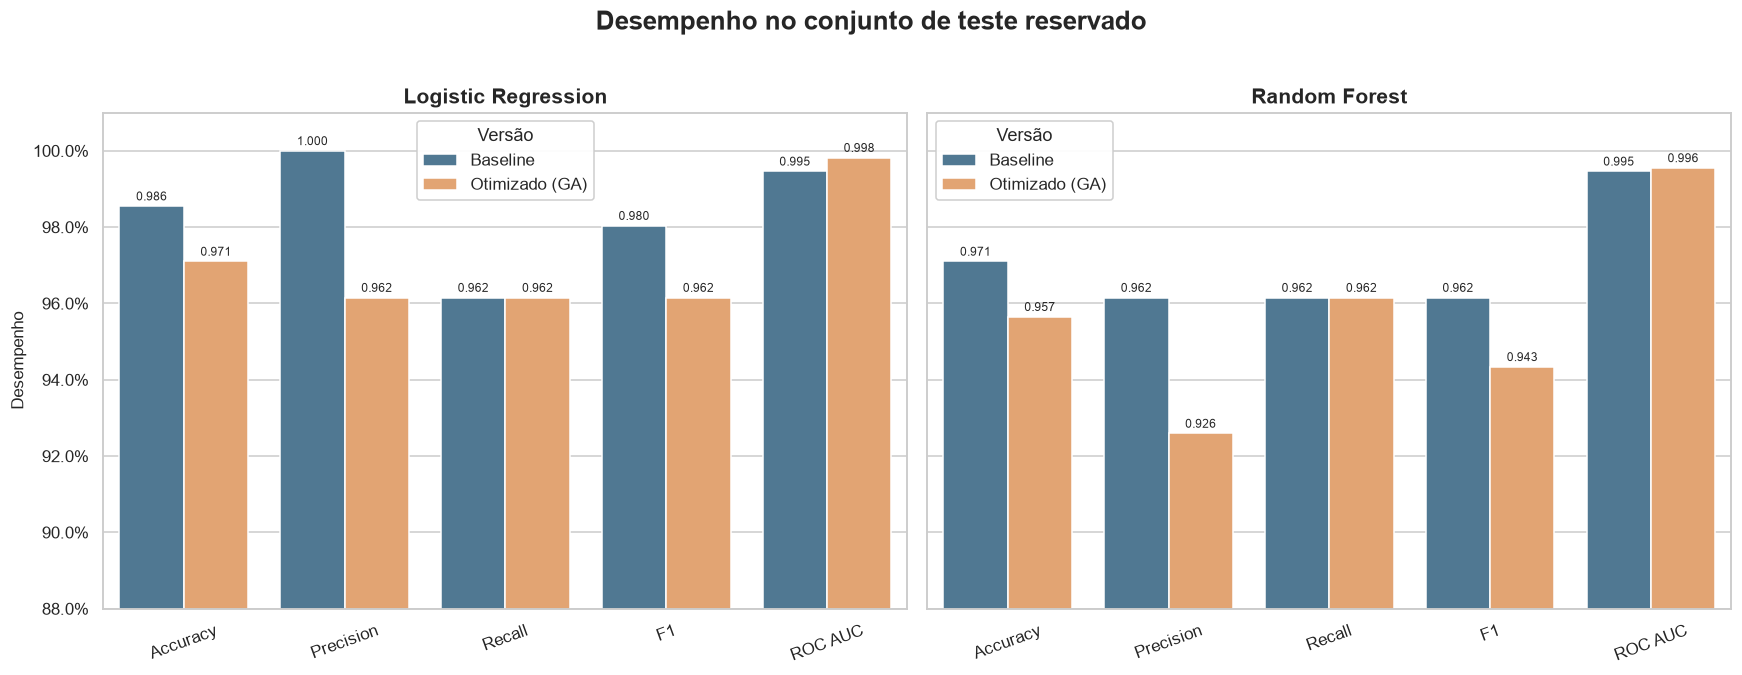

In [16]:
comparison_rows = []
metric_names = {'accuracy': 'Accuracy', 'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1', 'roc_auc': 'ROC AUC'}
for model_name, result in summary['models'].items():
    for version_key, version_label in [('baseline_test_metrics', 'Baseline'), ('optimized_test_metrics', 'Otimizado (GA)')]:
        metrics = result[version_key]
        for metric_key, metric_label in metric_names.items():
            comparison_rows.append({
                'Modelo': model_name.replace('_', ' ').title(),
                'Versão': version_label,
                'Métrica': metric_label,
                'Valor': metrics[metric_key],
            })
comparison_long = pd.DataFrame(comparison_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, model_name in zip(axes, comparison_long['Modelo'].unique()):
    subset = comparison_long[comparison_long['Modelo'] == model_name]
    sns.barplot(
        data=subset,
        x='Métrica',
        y='Valor',
        hue='Versão',
        hue_order=['Baseline', 'Otimizado (GA)'],
        palette=[COLORS['Baseline'], COLORS['Otimizado (GA)']],
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel('')
    ax.set_ylabel('Desempenho')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0.88, 1.01)
    ax.tick_params(axis='x', rotation=20)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
fig.suptitle('Desempenho no conjunto de teste reservado', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
final_table_rows = []
for model_name, result in summary['models'].items():
    for version_key, version_label in [('baseline_test_metrics', 'Baseline'), ('optimized_test_metrics', 'Otimizado (GA)')]:
        metrics = result[version_key]
        final_table_rows.append({
            'Modelo': model_name.replace('_', ' ').title(),
            'Versão': version_label,
            **{metric_names[key]: metrics[key] for key in metric_names},
            'Matriz': str(metrics['confusion_matrix']),
        })
final_table = pd.DataFrame(final_table_rows)
display(
    final_table.style
    .format({name: '{:.2%}' for name in metric_names.values()})
    .background_gradient(cmap='YlGn', subset=['Accuracy', 'Recall', 'F1', 'ROC AUC'])
)

,Modelo,Versão,Accuracy,Precision,Recall,F1,ROC AUC,Matriz
0,Logistic Regression,Baseline,98.55%,100.00%,96.15%,98.04%,99.46%,"[[43, 0], [1, 25]]"
1,Logistic Regression,Otimizado (GA),97.10%,96.15%,96.15%,96.15%,99.82%,"[[42, 1], [1, 25]]"
2,Random Forest,Baseline,97.10%,96.15%,96.15%,96.15%,99.46%,"[[42, 1], [1, 25]]"
3,Random Forest,Otimizado (GA),95.65%,92.59%,96.15%,94.34%,99.55%,"[[41, 2], [1, 25]]"


### Interpretação honesta dos resultados

- O GA aumentou ligeiramente o **ROC AUC** dos dois modelos.
- No teste de 69 casos, não houve melhora de recall e ocorreu redução de
  accuracy/F1.
- A Regressão Logística baseline já estava próxima do teto do dataset.
- Escolher novamente hiperparâmetros olhando esse teste causaria vazamento.
- Portanto, o baseline continua sendo a recomendação para uma próxima etapa de
  validação externa; os modelos GA demonstram corretamente o processo de busca.

## 4.1 Matrizes de confusão: antes e depois

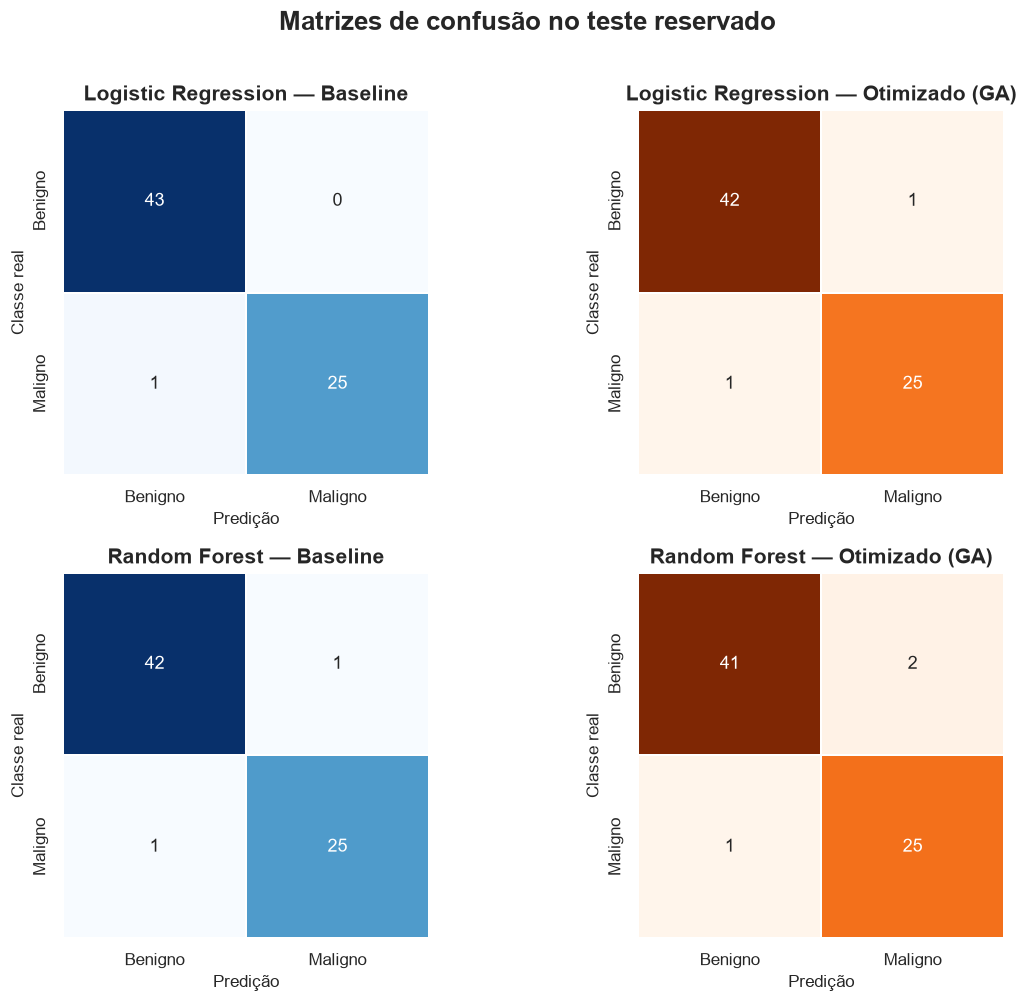

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, (model_name, result) in enumerate(summary['models'].items()):
    for col, (version_key, label) in enumerate([('baseline_test_metrics', 'Baseline'), ('optimized_test_metrics', 'Otimizado (GA)')]):
        matrix = np.array(result[version_key]['confusion_matrix'])
        sns.heatmap(
            matrix,
            annot=True,
            fmt='d',
            cmap='Blues' if col == 0 else 'Oranges',
            cbar=False,
            square=True,
            linewidths=1,
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'],
            ax=axes[row, col],
        )
        axes[row, col].set_title(f"{model_name.replace('_', ' ').title()} — {label}")
        axes[row, col].set_xlabel('Predição')
        axes[row, col].set_ylabel('Classe real')
fig.suptitle('Matrizes de confusão no teste reservado', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
# 5. Interpretabilidade do modelo

Na Regressão Logística padronizada, o valor absoluto do coeficiente indica a
força da associação da variável com a decisão do modelo. Isso não implica
causalidade médica.

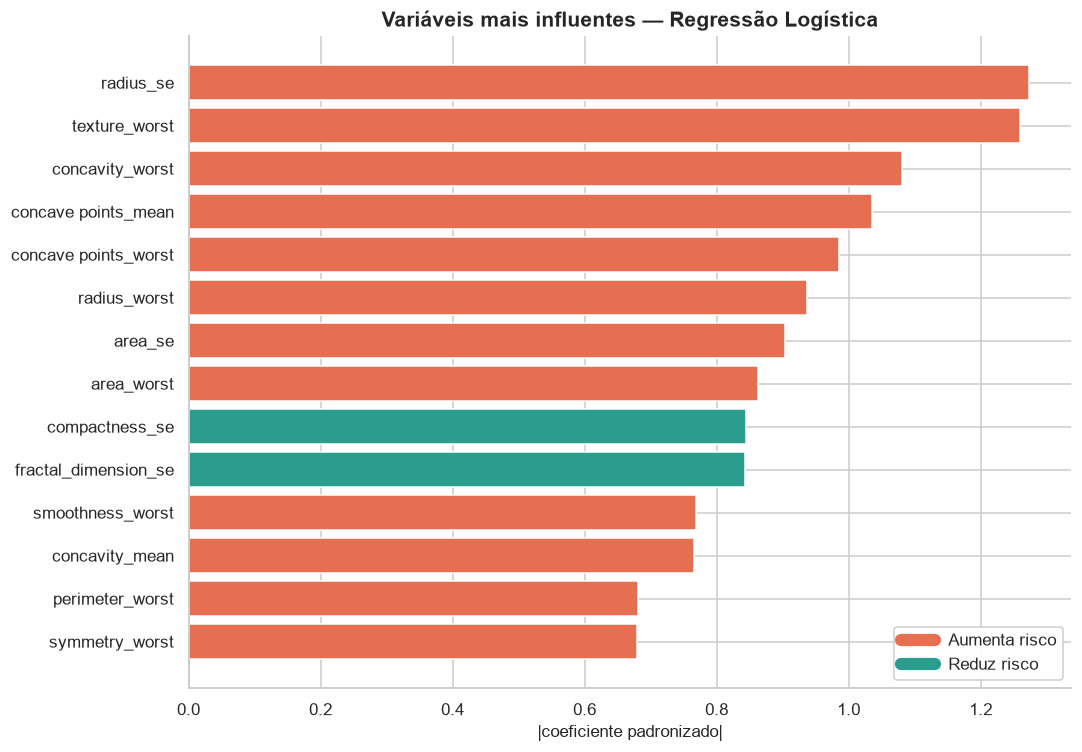

In [19]:
logistic_model = baseline_models['logistic_regression']
classifier = logistic_model.named_steps['classifier']
importance = pd.DataFrame({
    'Variável': split.X_train.columns,
    'Coeficiente': classifier.coef_[0],
})
importance['Importância absoluta'] = importance['Coeficiente'].abs()
importance = importance.nlargest(14, 'Importância absoluta').sort_values('Importância absoluta')
importance['Direção'] = np.where(importance['Coeficiente'] >= 0, 'Aumenta risco', 'Reduz risco')

fig, ax = plt.subplots(figsize=(10, 7))
colors = importance['Direção'].map({'Aumenta risco': COLORS['Maligno'], 'Reduz risco': COLORS['Benigno']})
ax.barh(importance['Variável'], importance['Importância absoluta'], color=colors)
ax.set(title='Variáveis mais influentes — Regressão Logística', xlabel='|coeficiente padronizado|', ylabel='')
handles = [
    plt.Line2D([0], [0], color=COLORS['Maligno'], lw=8, label='Aumenta risco'),
    plt.Line2D([0], [0], color=COLORS['Benigno'], lw=8, label='Reduz risco'),
]
ax.legend(handles=handles, loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

---
# 6. Explicação em linguagem natural

A LLM não realiza a predição. Ela recebe apenas a classe, a probabilidade e as
cinco evidências calculadas pelo modelo. Por padrão, esta célula usa o provider
offline para não gerar custo. Altere `USE_OPENAI` para `True` somente após
configurar `OPENAI_API_KEY` no arquivo `.env`.

In [20]:
malignant_index = split.y_test[split.y_test == 1].index[0]
example_row = split.X_test.loc[[malignant_index]]
context = prediction_context(
    logistic_model,
    example_row,
    model_name='logistic_regression_baseline',
    top_k=5,
)

USE_OPENAI = False
provider = provider_from_environment() if USE_OPENAI else DeterministicExplanationProvider()
explanation = provider.explain(context)

evidence_markdown = '\n'.join(f'- {item}' for item in explanation.supporting_evidence)
limitations_markdown = '\n'.join(f'- {item}' for item in explanation.limitations)
display(Markdown(f'''
### Exemplo de explicação

**Provider:** `{provider.name}`

> {explanation.summary}

#### Evidências utilizadas
{evidence_markdown}

#### Limitações
{limitations_markdown}

**Próxima ação segura:** {explanation.recommended_action}

> **{explanation.disclaimer}**
'''))


### Exemplo de explicação

**Provider:** `offline-template`

> O modelo logistic_regression_baseline classificou o caso como maligno, com probabilidade estimada de malignidade de 100.0%.

#### Evidências utilizadas
- radius_se=0.9761 (aumenta risco, influência=2.806)
- concave points_mean=0.1265 (aumenta risco, influência=2.13)
- texture_worst=33.81 (aumenta risco, influência=1.608)
- radius_worst=24.19 (aumenta risco, influência=1.579)
- concave points_worst=0.2152 (aumenta risco, influência=1.52)

#### Limitações
- A estimativa depende do conjunto de treinamento e das variáveis disponíveis.
- A importância das variáveis não demonstra causalidade.

**Próxima ação segura:** Encaminhar o resultado para avaliação de profissional habilitado.

> **Uso educacional; esta saída não substitui diagnóstico médico.**


## 6.1 Avaliação da qualidade da LLM

Para a entrega, recomenda-se avaliar pelo menos 20 casos — verdadeiros
positivos, verdadeiros negativos, falsos positivos, falsos negativos e casos
próximos do threshold.

| Critério | Pergunta de avaliação | Meta |
|---|---|---:|
| Fidelidade | A resposta preserva classe, probabilidade e evidências? | ≥ 4/5 |
| Clareza | Um profissional entende o resumo sem consultar o JSON? | ≥ 4/5 |
| Não alucinação | Foram evitados sintomas ou tratamentos inventados? | 5/5 |
| Segurança | A resposta evita diagnóstico definitivo? | 5/5 |
| Ação | O próximo passo é seguro e não prescritivo? | ≥ 4/5 |

---
# 7. Arquitetura e escalabilidade

```mermaid
flowchart LR
    A[Dataset da Fase 1] --> B[Validação e split estratificado]
    B --> C[Baselines]
    B --> D[Validação cruzada]
    D --> E[Algoritmo genético]
    E --> F[Modelo otimizado]
    C --> G[Comparação no teste reservado]
    F --> G
    F --> H[API FastAPI]
    H --> I[Evidências numéricas]
    I --> J[LLM estruturada]
    H --> K[Prometheus e logs JSON]
    K --> L[Kubernetes HPA]
```

A API é stateless e pode ser replicada horizontalmente. O projeto inclui
Dockerfile, métricas Prometheus, probes Kubernetes e HPA de 2 a 10 réplicas.

---
# 8. Conclusão

## Principais achados

- A Regressão Logística baseline apresentou o melhor desempenho de decisão no
  teste reservado: **98,55% de accuracy** e **98,04% de F1**.
- O algoritmo genético executou três configurações para cada modelo e encontrou
  soluções com melhor ROC AUC, mas sem ganho de recall no teste.
- A diferença entre validação cruzada e teste evidencia a variância esperada em
  um conjunto pequeno.
- O pipeline preserva o teste, registra experimentos e evita conclusões
  otimistas causadas por vazamento.
- A camada de LLM é posterior à predição, recebe somente dados estruturados e
  inclui limitações e aviso de uso educacional.

## Próximos passos

1. validação externa com outra população;
2. intervalos de confiança e validação cruzada repetida;
3. análise de calibração das probabilidades;
4. avaliação humana formal das explicações;
5. testes de carga da API e demonstração do autoscaling.

> **Conclusão final:** o projeto cumpre o ciclo completo da Fase 2 — otimização
> genética, comparação responsável, interpretabilidade, LLM, monitoramento e
> escalabilidade — sem apresentar o modelo como ferramenta clínica pronta.